# Train the best model for predicting who to call

The notebook that came with the problem: somebody's attempt at predicting which clients subscribe to a term
deposit. There is no name on it and nobody left to ask about it - only the notes left behind along the way.

**Those notes are marked: 📝**

In [1]:
import pickle
from pathlib import Path

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

📝: The campaign export came as a CSV. I got tired of re-typing `sep=";"` and of pandas guessing a
column type from whichever rows it happened to read first, so I converted it once to parquet and never opened the
CSV again. Parquet keeps the column types next to the data and the file is far smaller, which I notice every time
the kernel restarts. It restarts a lot.

Both files are on the course platform. Put them in `data/` next to this project; git ignores that folder.

In [2]:
# At least it's not hardcoded...
project_root = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
data_path = project_root / "data" / "dataset.parquet"
assert data_path.is_file(), f"{data_path} is missing - download the dataset from Moodle into data/"

df = pd.read_parquet(data_path)
print(f"loaded {df.shape[0]} rows and {df.shape[1]} columns")

loaded 41188 rows and 21 columns


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

<Axes: xlabel='age', ylabel='Count'>

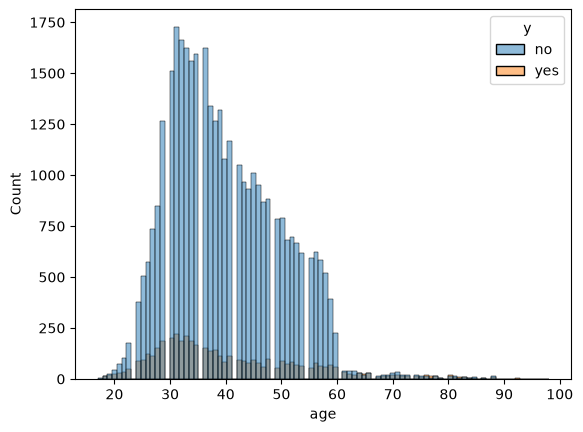

In [4]:
sns.histplot(df, x="age", hue="y")

📝: The target is `y` - did the client subscribe to the term deposit after the campaign call.

In [5]:
y = df.y.replace({"yes": 1, "no": 0})
print(f"positive rate: {y.mean():.3f}")

positive rate: 0.113


/tmp/ipykernel_856998/2968462938.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df.y.replace({"yes": 1, "no": 0})


📝: About one client in nine says yes...

Answering "no" to every single client already scores whatever you see printed above, subtracted from one, so the model looks good by doing nothing.
The question that actually matters is of the clients we decide to call, how many subscribe?

Calling costs money, and that number is precision.
Its mirror image is recall, the share of subscribers we managed to reach, and the two move in opposite directions when you change
the probability above which you call someone. `predict_proba` gives the probability; 0.5 is just a default, not a
decision anybody made.

So six numbers are reported now, further down. They took an afternoon and they were worth it.

📝: `duration` is off limits - nobody knows the call duration before the call ends.
I wrapped that up with the target mapping so I stop forgetting one of the two.

In [6]:
def prepare(frame):
    """Split a raw frame into model inputs and 0/1 labels."""
    labels = (frame["y"] == "yes").astype(int)
    features = frame.drop(columns=["y", "duration"])
    return features, labels


features, labels = prepare(df)
print(f"{features.shape[1]} features left once y and duration are out")

19 features left once y and duration are out


In [7]:
def split(features, labels, test_size=0.2, val_size=0.2, seed=0):
    """Train/val/test. Stratified: with 11% positives an unlucky split moves every metric."""
    train_x, test_x, train_y, test_y = train_test_split(
        features, labels, test_size=test_size, random_state=seed, stratify=labels
    )
    train_x, val_x, train_y, val_y = train_test_split(
        train_x, train_y, test_size=val_size, random_state=seed, stratify=train_y
    )
    return train_x, val_x, test_x, train_y, val_y, test_y


train_x, val_x, test_x, train_y, val_y, test_y = split(features, labels)
print(f"train {len(train_x)} | val {len(val_x)} | test {len(test_x)}")

train 26360 | val 6590 | test 8238


# Training

📝: One thing to know before reading the pipeline: nobody in this dataset was ever called in January or
February.

A `OneHotEncoder` builds its columns from the values it sees while fitting, so left alone it would give the model
no January input at all, and the campaign starts again in the winter. Same story for the days of the week, on a
smaller scale. Those two columns have a list of values that is known in advance and has nothing to do with which
rows we happened to collect, so I pass the list in rather than let the encoder discover it. The other categorical
columns really do have to be learned from the data, so they are encoded separately.

In [8]:
df.month.value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

# Categories whose full list is known in advance, whatever the rows contain.
KNOWN_CATEGORIES = {
    "month": ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
    "day_of_week": ["sun", "mon", "tue", "wed", "thu", "fri", "sat"],
}
fixed_cat_cols = list(KNOWN_CATEGORIES)

# And the ones we have no choice but to learn from the training rows.
learned_cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]

📝: One `Pipeline` holding both the preprocessing and the classifier, so there is a single object to
save and a single object to call. The two steps are named `data_processor` and `model` - please keep those
names, whatever you do with this code afterwards.

In [10]:
def make_pipeline(n_estimators=100, max_depth=8, seed=0):
    """Preprocessing + classifier as one artifact."""
    data_processor = ColumnTransformer(
        [
            ("numerical", StandardScaler(), num_cols),
            # Explicit categories: twelve month columns and five weekday columns exist
            # whether or not anyone was called in January.
            (
                "categorical_fixed",
                OneHotEncoder(categories=[KNOWN_CATEGORIES[c] for c in fixed_cat_cols], handle_unknown="ignore"),
                fixed_cat_cols,
            ),
            ("categorical_learned", OneHotEncoder(handle_unknown="infrequent_if_exist"), learned_cat_cols),
        ]
    )
    return Pipeline(
        [
            ("data_processor", data_processor),
            ("model", RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=seed)),
        ]
    )


pipeline = make_pipeline()
forest = pipeline.named_steps["model"]
print(f"pipeline: {forest.n_estimators} trees, max depth {forest.max_depth}, seed {forest.random_state}")

pipeline: 100 trees, max depth 8, seed 0


In [11]:
%%time
pipeline.fit(train_x, train_y)
print(f"fitted on {len(train_x)} rows")

fitted on 26360 rows
CPU times: user 2.35 s, sys: 14.4 ms, total: 2.36 s
Wall time: 2.36 s


📝: The six numbers, in one function so I stop reporting a different set every week.

`positive_rate` is there so nobody reads `accuracy` without it. `precision` and `recall` describe one operating
point, the threshold. `roc_auc` and `average_precision` describe the ranking at every threshold at once, which is
what you compare between two runs when the threshold is still being argued about. On data this unbalanced,
`average_precision` (the area under the precision-recall curve) is the honest one: `roc_auc` stays flattering
because true negatives are plentiful and cost nothing.

In [12]:
def evaluate(model, x, y, threshold=0.5):
    """Everything worth reporting about a fitted model on one split."""
    probabilities = model.predict_proba(x)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return {
        "positive_rate": float(y.mean()),
        "accuracy": accuracy_score(y, predictions),
        # zero_division=0: a model that never predicts a subscriber has no precision.
        "precision": precision_score(y, predictions, zero_division=0),
        "recall": recall_score(y, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities),
    }


val_metrics = evaluate(pipeline, val_x, val_y)
print("--- validation ---")
for name, value in val_metrics.items():
    print(f"{name}: {value:.3f}")

--- validation ---
positive_rate: 0.113
accuracy: 0.902
precision: 0.720
recall: 0.212
roc_auc: 0.802
average_precision: 0.480


📝: And the curves, because a single threshold never tells you what the model is capable of.

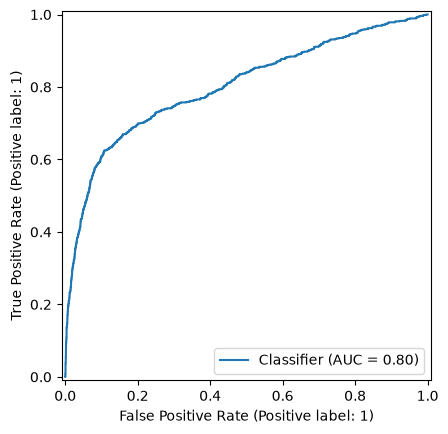

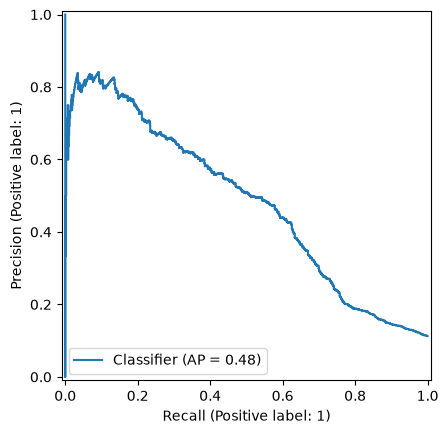

In [13]:
val_probabilities = pipeline.predict_proba(val_x)[:, 1]
RocCurveDisplay.from_predictions(val_y, val_probabilities)
PrecisionRecallDisplay.from_predictions(val_y, val_probabilities)

📝: The same thing as a table, since the curves are hard to read a number off. Every row is a different
answer to "how sure do we have to be before we spend a phone call on someone". The model is left at 0.5 because I
did not know who to ask, but that is a business decision and somebody should make it on purpose.

In [14]:
# Why use scikit-learn's builtins, when you can DIY your Hyperparameter search...
sweep = pd.DataFrame(
    [{"threshold": t, **evaluate(pipeline, val_x, val_y, threshold=t)} for t in [0.2, 0.3, 0.4, 0.5, 0.6]]
)
sweep[["threshold", "accuracy", "precision", "recall"]].round(3)

,threshold,accuracy,precision,recall
0,0.2,0.877,0.462,0.580
1,0.3,0.887,0.497,0.513
2,0.4,0.902,0.621,0.332
3,0.5,0.902,0.720,0.212
4,0.6,0.901,0.776,0.173


📝: This package seems pretty cool, I've seen Intel give a good talk about it, it's about time we try it.

In [15]:
! pip install scikit-learn-intelex

zsh:1: command not found: pip


In [16]:
from sklearnex import patch_sklearn

patch_sklearn()

ModuleNotFoundError: No module named 'sklearnex'

📝: Patched! I think it is supposed to go before the sklearn imports, but the fit cell did feel faster when I re-ran it. Good enough for me.

In [17]:
test_metrics = evaluate(pipeline, test_x, test_y)
print("--- test ---")
for name, value in test_metrics.items():
    print(f"{name}: {value:.3f}")

--- test ---
positive_rate: 0.113
accuracy: 0.899
precision: 0.680
recall: 0.195
roc_auc: 0.797
average_precision: 0.455


📝: Those are decent numbers. Time to save the model.

In [ ]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print(f"saved best_model.pkl ({Path('best_model.pkl').stat().st_size / 1e6:.1f} MB)")

📝: Works on my machine 🎉 The API part is somebody else's problem.

Everything this notebook did is printed above, so scroll up if you need to know what ran. I kept meaning to look
into the `logging` module, but `print` never let me down.